# 15 - Hero Figure Candidates for the README

**This notebook does not train or select anything.** It loads the already-serialized
final model (`models/xgb_final.joblib`) and the already-produced `test.parquet`, scores
the frozen model (inference only), and renders four candidate figures for the README's
"hero" image. Pick one after reviewing all four - none is committed by this notebook.

In [1]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path('..').resolve()))
from src.data import load_split, FEATURE_SET, CATEGORICAL_COLS
from src.features import build_features, prepare_X
from src.economics import compute_interest_loss, profit_at_threshold

FIGURES_DIR = Path('..') / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Sober, colorblind-safe palette (Okabe-Ito), reused across the whole project
COLOR_MODEL = '#E69F00'      # XGB_walkforward
COLOR_BASELINE = '#888888'   # approve-all / random reference
COLOR_MARK = '#D55E00'       # optimal point / callout
COLOR_BLUE = '#0072B2'       # subgroup bars
COLOR_GREEN = '#009E73'      # avoided loss
COLOR_RED = '#D55E00'        # forgone interest

THRESH_XGB = 0.31


## Load the frozen model and score the test set (inference only)

In [2]:
train = load_split('train')
test = load_split('test')

X_train = prepare_X(build_features(train), FEATURE_SET, CATEGORICAL_COLS)
test_feat = build_features(test)
X_test = prepare_X(test_feat, FEATURE_SET, CATEGORICAL_COLS).reindex(columns=X_train.columns, fill_value=0)
y_test = test_feat['target'].values

interest_test, loss_test = compute_interest_loss(test_feat)
interest_test, loss_test = interest_test.values, loss_test.values

xgb_final = joblib.load(Path('..') / 'models' / 'xgb_final.joblib')
y_prob = xgb_final.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_prob)
profit_m0b = interest_test[y_test == 0].sum() - loss_test[y_test == 1].sum()
profit_xgb = profit_at_threshold(y_test, y_prob, THRESH_XGB, interest_test, loss_test)

print(f'N test = {len(test)} | AUC-ROC = {auc_test:.4f}')
print(f'Profit approve-all (M0b) = $ {profit_m0b:,.2f}')
print(f'Profit XGB @ {THRESH_XGB} = $ {profit_xgb:,.2f}')
print(f'Gain over approve-all = $ {profit_xgb - profit_m0b:,.2f}')


N test = 282787 | AUC-ROC = 0.6846
Profit approve-all (M0b) = $ 233,202,813.06
Profit XGB @ 0.31 = $ 242,230,710.89
Gain over approve-all = $ 9,027,897.83


## Figure 1 - Profit curve by threshold (`profit_curve.png`)

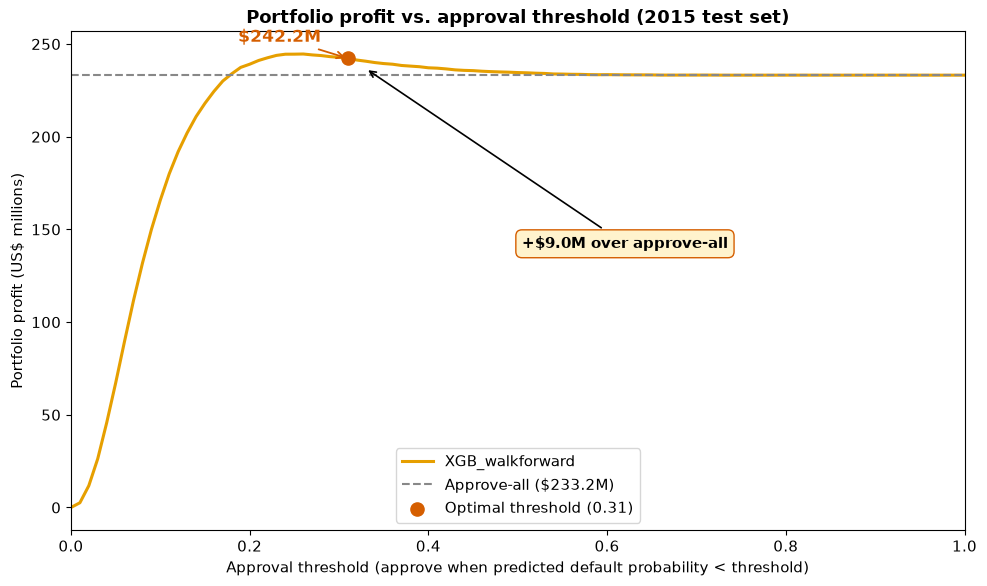

In [3]:
threshold_grid = np.round(np.arange(0.0, 1.001, 0.01), 2)
profits = np.array([profit_at_threshold(y_test, y_prob, t, interest_test, loss_test) for t in threshold_grid])

best_idx = int(np.argmin(np.abs(threshold_grid - THRESH_XGB)))
best_t = threshold_grid[best_idx]
best_profit = profits[best_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_grid, profits / 1e6, color=COLOR_MODEL, linewidth=2.2, label='XGB_walkforward')
ax.axhline(profit_m0b / 1e6, color=COLOR_BASELINE, linestyle='--', linewidth=1.5,
           label=f'Approve-all (${profit_m0b / 1e6:.1f}M)')
ax.scatter([best_t], [best_profit / 1e6], color=COLOR_MARK, zorder=5, s=90,
           label=f'Optimal threshold ({best_t:.2f})')
ax.annotate(f'${best_profit / 1e6:.1f}M', xy=(best_t, best_profit / 1e6),
            xytext=(best_t - 0.03, best_profit / 1e6 + 9),
            ha='right', fontsize=12, fontweight='bold', color=COLOR_MARK,
            arrowprops=dict(arrowstyle='->', color=COLOR_MARK, lw=1.3))
ax.annotate('+$9.0M over approve-all', xy=(best_t + 0.02, (best_profit / 1e6 + profit_m0b / 1e6) / 2 - 1),
            xytext=(0.62, 140),
            fontsize=11, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor=COLOR_MARK))

ax.set_xlabel('Approval threshold (approve when predicted default probability < threshold)')
ax.set_ylabel('Portfolio profit (US$ millions)')
ax.set_title('Portfolio profit vs. approval threshold (2015 test set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower center')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'profit_curve.png', dpi=150, facecolor='white')
plt.show()


## Figure 2 - Default-capture (lift) curve (`lift_curve.png`)

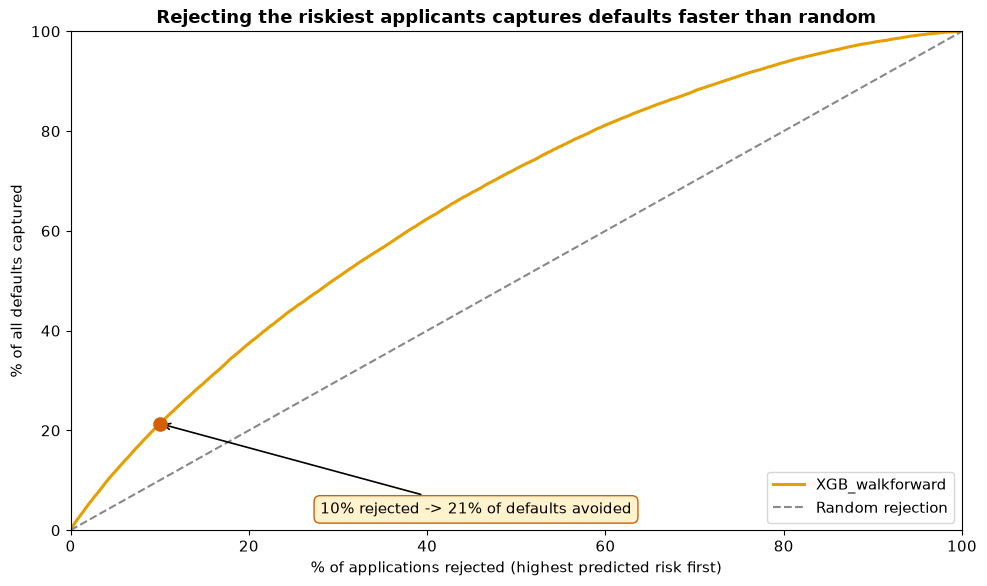

In [4]:
order = np.argsort(-y_prob)
y_sorted = y_test[order]
cum_defaults = np.cumsum(y_sorted)
total_defaults = y_test.sum()
n = len(y_test)

pct_rejected = np.arange(1, n + 1) / n * 100
pct_captured = cum_defaults / total_defaults * 100

idx10 = int(n * 0.10)
capture_at_10 = cum_defaults[idx10 - 1] / total_defaults * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pct_rejected, pct_captured, color=COLOR_MODEL, linewidth=2.2, label='XGB_walkforward')
ax.plot([0, 100], [0, 100], color=COLOR_BASELINE, linestyle='--', linewidth=1.5, label='Random rejection')
ax.scatter([10], [capture_at_10], color=COLOR_MARK, zorder=5, s=90)
ax.annotate(f'10% rejected -> {capture_at_10:.0f}% of defaults avoided', xy=(10, capture_at_10),
            xytext=(28, capture_at_10 - 18),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', edgecolor=COLOR_MARK))

ax.set_xlabel('% of applications rejected (highest predicted risk first)')
ax.set_ylabel('% of all defaults captured')
ax.set_title('Rejecting the riskiest applicants captures defaults faster than random', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lift_curve.png', dpi=150, facecolor='white')
plt.show()


## Figure 3 - Profit decomposition at threshold 0.31 (`profit_decomposition.png`)

In [5]:
rejected = y_prob >= THRESH_XGB
rejected_charged_off = rejected & (y_test == 1)
rejected_fully_paid = rejected & (y_test == 0)

avoided_loss = loss_test[rejected_charged_off].sum()
forgone_interest = interest_test[rejected_fully_paid].sum()
net_gain = avoided_loss - forgone_interest

print(f'Avoided loss:     $ {avoided_loss:,.2f}')
print(f'Forgone interest: $ {forgone_interest:,.2f}')
print(f'Net gain:         $ {net_gain:,.2f}  (should match profit_xgb - profit_m0b above)')


Avoided loss:     $ 32,151,026.71
Forgone interest: $ 23,123,128.88
Net gain:         $ 9,027,897.83  (should match profit_xgb - profit_m0b above)


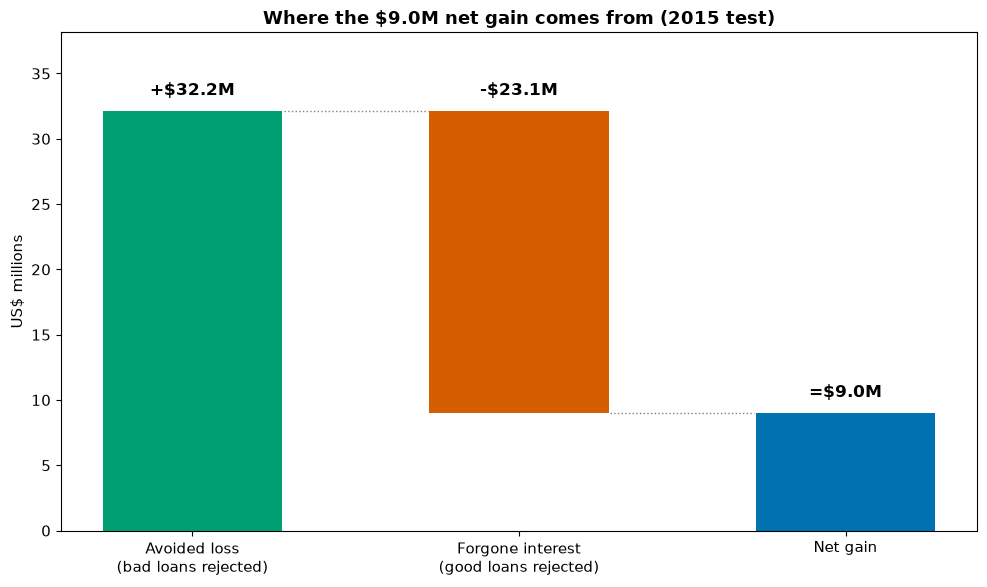

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

avoided_m = avoided_loss / 1e6
forgone_m = forgone_interest / 1e6
net_m = net_gain / 1e6

ax.bar(0, avoided_m, bottom=0, color=COLOR_GREEN, width=0.55)
ax.bar(1, forgone_m, bottom=net_m, color=COLOR_RED, width=0.55)
ax.bar(2, net_m, bottom=0, color=COLOR_BLUE, width=0.55)

ax.plot([0.28, 0.72], [avoided_m, avoided_m], color='gray', linestyle=':', linewidth=1)
ax.plot([1.28, 1.72], [net_m, net_m], color='gray', linestyle=':', linewidth=1)

for x, top, label in [(0, avoided_m, f'+${avoided_m:.1f}M'),
                       (1, avoided_m, f'-${forgone_m:.1f}M'),
                       (2, net_m, f'=${net_m:.1f}M')]:
    ax.text(x, top + 1.2, label, ha='center', fontsize=12, fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Avoided loss\n(bad loans rejected)', 'Forgone interest\n(good loans rejected)', 'Net gain'])
ax.set_ylabel('US$ millions')
ax.set_title('Where the $9.0M net gain comes from (2015 test)', fontsize=13, fontweight='bold')
ax.set_ylim(0, avoided_m + 6)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'profit_decomposition.png', dpi=150, facecolor='white')
plt.show()


## Figure 4 - AUC by subgroup, the honest limitation (`subgroup_auc.png`)

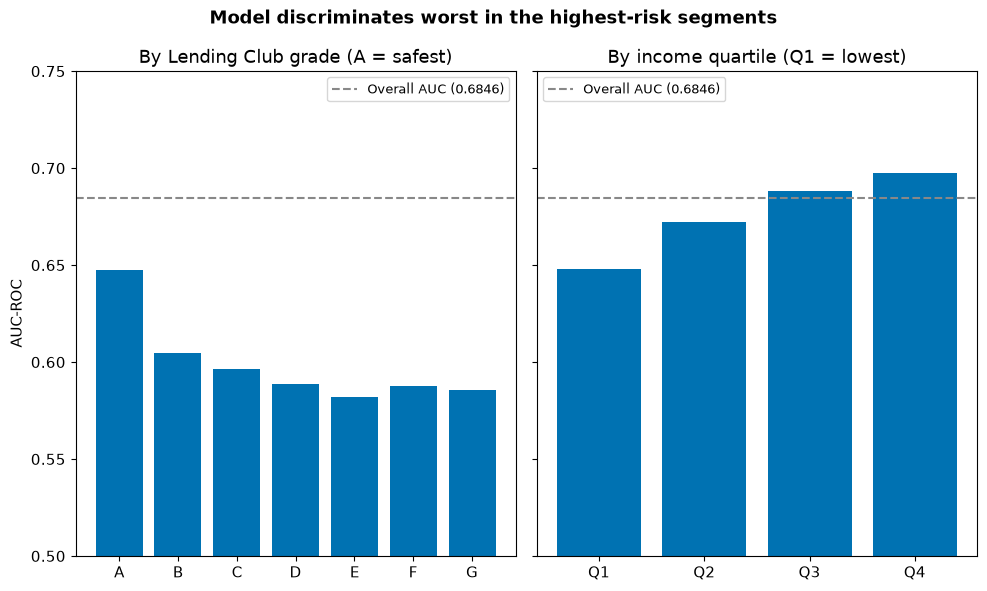

In [7]:
grade_rows = []
for g in sorted(test['grade'].dropna().unique()):
    mask = (test['grade'] == g).values
    if mask.sum() >= 2 and len(np.unique(y_test[mask])) == 2:
        grade_rows.append((g.upper(), roc_auc_score(y_test[mask], y_prob[mask])))
grades, grade_aucs = zip(*grade_rows)

income_q = pd.qcut(test['annual_inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
income_rows = []
for q in income_q.cat.categories:
    mask = (income_q == q).values
    income_rows.append((str(q), roc_auc_score(y_test[mask], y_prob[mask])))
incomes, income_aucs = zip(*income_rows)

overall_auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

axes[0].bar(grades, grade_aucs, color=COLOR_BLUE)
axes[0].axhline(overall_auc, color=COLOR_BASELINE, linestyle='--', linewidth=1.5,
                label=f'Overall AUC ({overall_auc:.4f})')
axes[0].set_title('By Lending Club grade (A = safest)')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_ylim(0.5, 0.75)
axes[0].legend(loc='upper right', fontsize=9)

axes[1].bar(incomes, income_aucs, color=COLOR_BLUE)
axes[1].axhline(overall_auc, color=COLOR_BASELINE, linestyle='--', linewidth=1.5,
                label=f'Overall AUC ({overall_auc:.4f})')
axes[1].set_title('By income quartile (Q1 = lowest)')
axes[1].legend(loc='upper left', fontsize=9)

fig.suptitle('Model discriminates worst in the highest-risk segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'subgroup_auc.png', dpi=150, facecolor='white')
plt.show()


## Report: files written

In [8]:
for fname in ['profit_curve.png', 'lift_curve.png', 'profit_decomposition.png', 'subgroup_auc.png']:
    fpath = FIGURES_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    print(f'{fpath} - {size_kb:.1f} KB')


..\reports\figures\profit_curve.png - 84.1 KB
..\reports\figures\lift_curve.png - 97.5 KB
..\reports\figures\profit_decomposition.png - 47.2 KB
..\reports\figures\subgroup_auc.png - 48.1 KB


Four candidates generated in `reports/figures/`. None of them, and no other change,
has been committed by this notebook - pick a "hero" and commit deliberately.